In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [41]:
df = pd.read_csv("Walmart_Sales.csv")

df.head()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [42]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (6435, 8)

Columns:
['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

Data Types:
Store             int64
Date             object
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

Missing Values:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

Duplicate Rows: 0


In [43]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


In [44]:
print(df['Date'].min())
print(df['Date'].max())

2010-02-05 00:00:00
2012-10-26 00:00:00


In [45]:
df.describe()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885


In [46]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Day'] = df['Date'].dt.day

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Day
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6,12
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7,19
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8,26
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,5


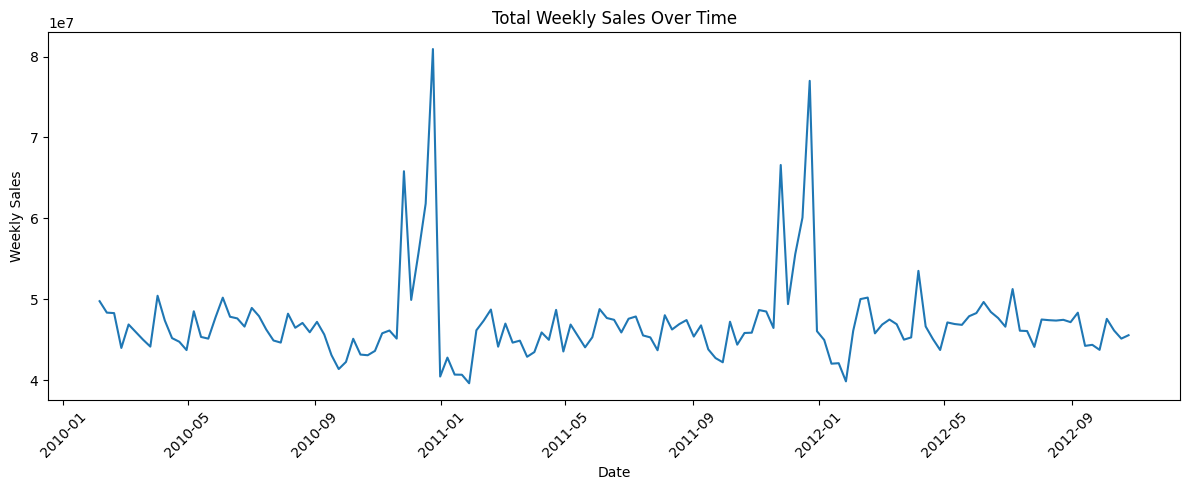

In [47]:
plt.figure(figsize=(12, 5))

weekly_sales = df.groupby('Date')['Weekly_Sales'].sum()

plt.plot(weekly_sales.index, weekly_sales.values)

plt.title('Total Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

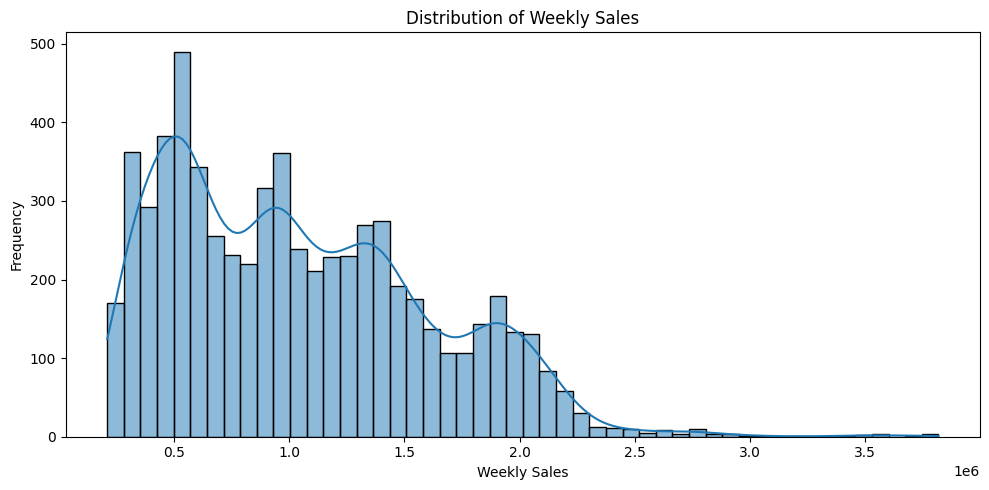

In [48]:
plt.figure(figsize=(10, 5))

sns.histplot(df['Weekly_Sales'], bins=50, kde=True)

plt.title('Distribution of Weekly Sales')
plt.xlabel('Weekly Sales')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

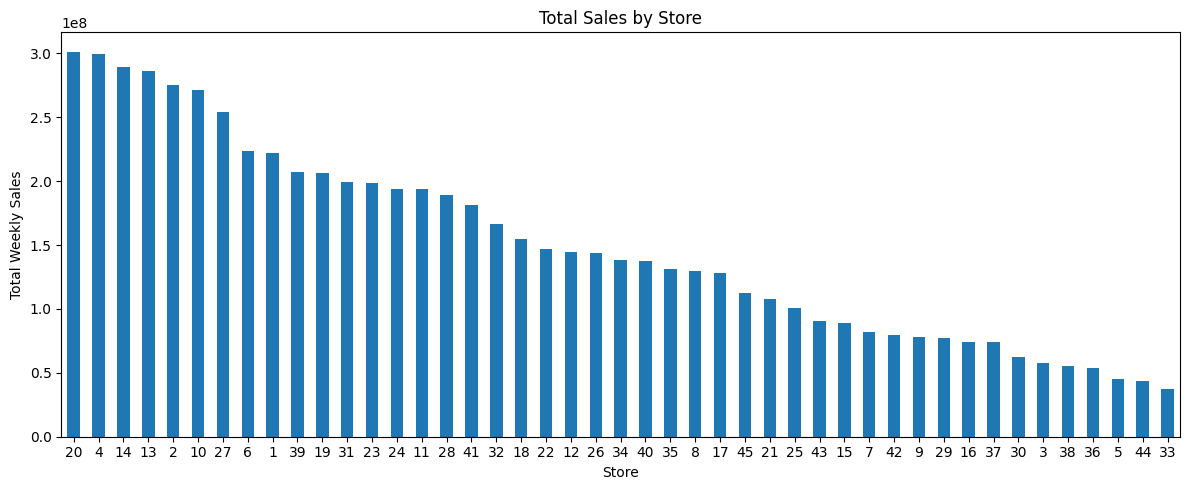

In [49]:
store_sales = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))

store_sales.plot(kind='bar')

plt.title('Total Sales by Store')
plt.xlabel('Store')
plt.ylabel('Total Weekly Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

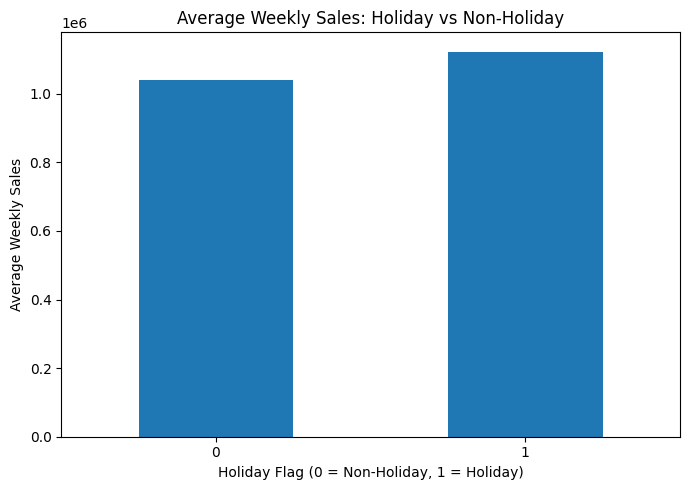

In [50]:
holiday_sales = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()

plt.figure(figsize=(7, 5))

holiday_sales.plot(kind='bar')

plt.title('Average Weekly Sales: Holiday vs Non-Holiday')
plt.xlabel('Holiday Flag (0 = Non-Holiday, 1 = Holiday)')
plt.ylabel('Average Weekly Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

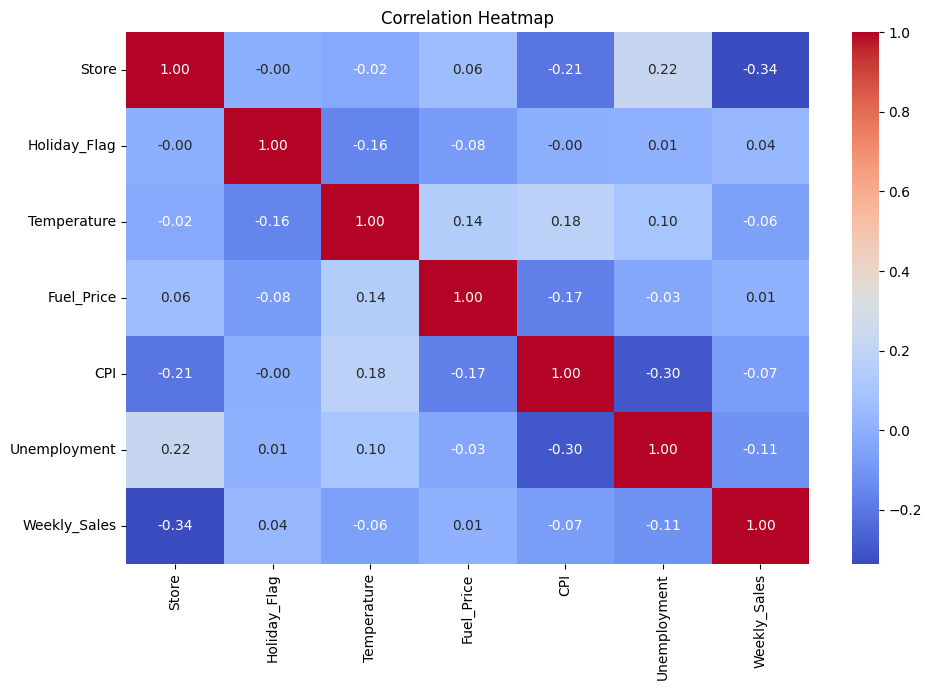

In [51]:
plt.figure(figsize=(10, 7))

numeric_cols = [
    'Store',
    'Holiday_Flag',
    'Temperature',
    'Fuel_Price',
    'CPI',
    'Unemployment',
    'Weekly_Sales'
]

correlation = df[numeric_cols].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

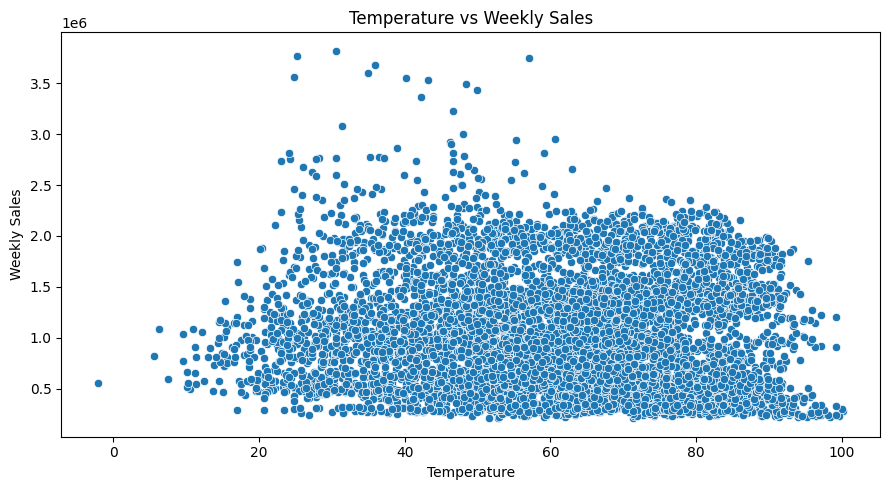

In [52]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x='Temperature',
    y='Weekly_Sales'
)

plt.title('Temperature vs Weekly Sales')
plt.xlabel('Temperature')
plt.ylabel('Weekly Sales')
plt.tight_layout()
plt.show()

In [53]:
import pandas as pd

df = pd.read_csv("Walmart_Sales.csv")
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Day'] = df['Date'].dt.day

# Features and target
features = [
    'Store',
    'Holiday_Flag',
    'Temperature',
    'Fuel_Price',
    'CPI',
    'Unemployment',
    'Year',
    'Month',
    'Week'
]

X = df[features]
y = df['Weekly_Sales']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (6435, 9)
Target shape: (6435,)


In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5148, 9)
Testing data: (1287, 9)


In [55]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

In [56]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression Results
-------------------------
MAE : 432594.97688780195
RMSE: 521583.50063959265
R²  : 0.15553160499602847


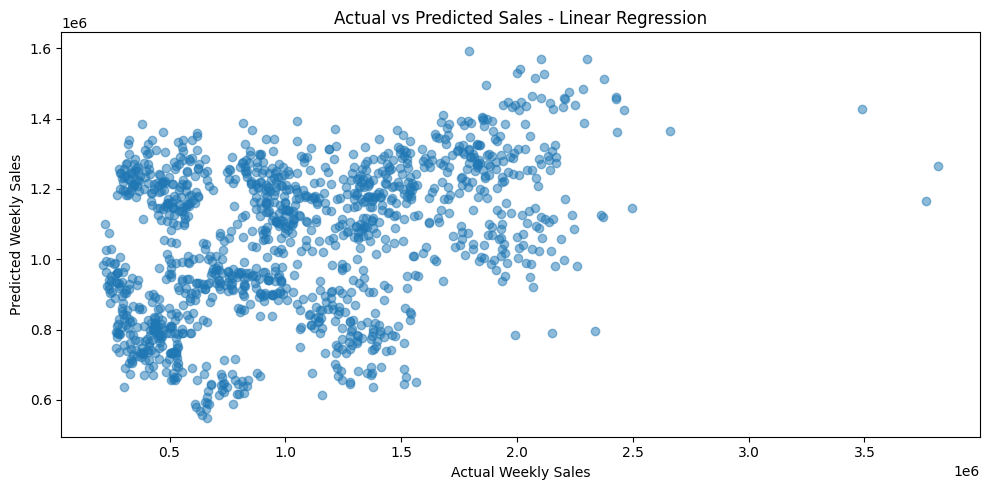

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.scatter(y_test, y_pred_lr, alpha=0.5)

plt.xlabel('Actual Weekly Sales')
plt.ylabel('Predicted Weekly Sales')
plt.title('Actual vs Predicted Sales - Linear Regression')

plt.tight_layout()
plt.show()

In [58]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [59]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Results
---------------------
MAE : 62022.51483061383
RMSE: 114106.3394247433
R²  : 0.9595838205436641


In [60]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest'
    ],
    'MAE': [
        mae_lr,
        mae_rf
    ],
    'RMSE': [
        rmse_lr,
        rmse_rf
    ],
    'R2': [
        r2_lr,
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,432594.976888,521583.500640,0.155532
1,Random Forest,62022.514831,114106.339425,0.959584


In [61]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
0,Store,0.663337
4,CPI,0.153930
5,Unemployment,0.104181
8,Week,0.050030
2,Temperature,0.012892
3,Fuel_Price,0.010295
7,Month,0.002867
1,Holiday_Flag,0.001594
6,Year,0.000874


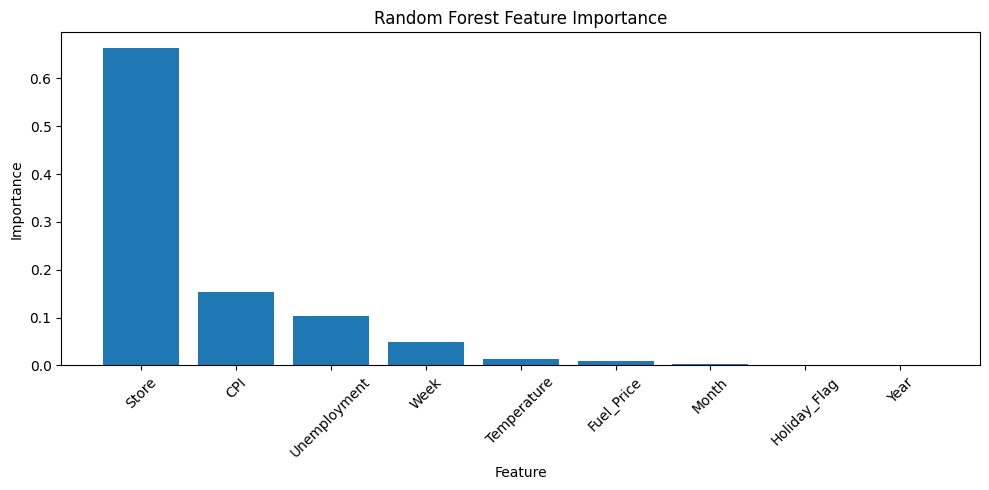

In [62]:
plt.figure(figsize=(10, 5))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [63]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

In [64]:
rf_base = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_grid,
    n_iter=15,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


RandomizedSearchCV(cv=3,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [65]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV RMSE:")
print(-random_search.best_score_)

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 20}

Best CV RMSE:
118374.5310001425


In [66]:
best_rf = random_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)

In [67]:
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned Random Forest Results")
print("---------------------------")
print("MAE :", mae_tuned)
print("RMSE:", rmse_tuned)
print("R²  :", r2_tuned)

Tuned Random Forest Results
---------------------------
MAE : 61914.55868006415
RMSE: 113307.31938484957
R²  : 0.9601478605750106


In [68]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Tuned Random Forest'
    ],
    'MAE': [
        mae_lr,
        mae_rf,
        mae_tuned
    ],
    'RMSE': [
        rmse_lr,
        rmse_rf,
        rmse_tuned
    ],
    'R2': [
        r2_lr,
        r2_rf,
        r2_tuned
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,432594.976888,521583.500640,0.155532
1,Random Forest,62022.514831,114106.339425,0.959584
2,Tuned Random Forest,61914.558680,113307.319385,0.960148


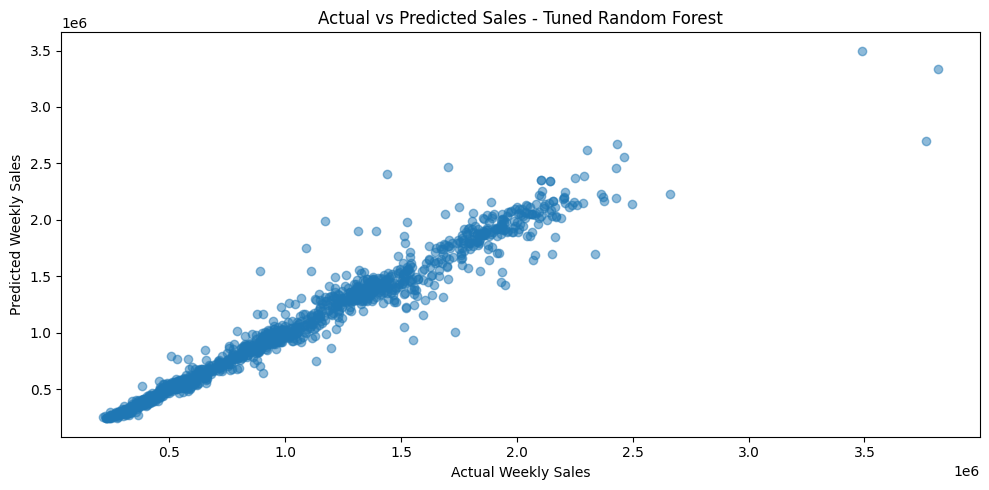

In [69]:
plt.figure(figsize=(10, 5))

plt.scatter(y_test, y_pred_tuned, alpha=0.5)

plt.xlabel('Actual Weekly Sales')
plt.ylabel('Predicted Weekly Sales')
plt.title('Actual vs Predicted Sales - Tuned Random Forest')

plt.tight_layout()
plt.show()

In [70]:
# Create monthly sales data

monthly_sales = df.groupby(
    df['Date'].dt.to_period('M')
)['Weekly_Sales'].sum()

monthly_sales = monthly_sales.to_timestamp()

monthly_sales.head()

,Weekly_Sales
Date,
2010-02-01,1.903330e+08
2010-03-01,1.819198e+08
2010-04-01,2.314124e+08
2010-05-01,1.867109e+08
2010-06-01,1.922462e+08


In [71]:
print("Number of months:", len(monthly_sales))
print("Start:", monthly_sales.index.min())
print("End:", monthly_sales.index.max())

Number of months: 33
Start: 2010-02-01 00:00:00
End: 2012-10-01 00:00:00


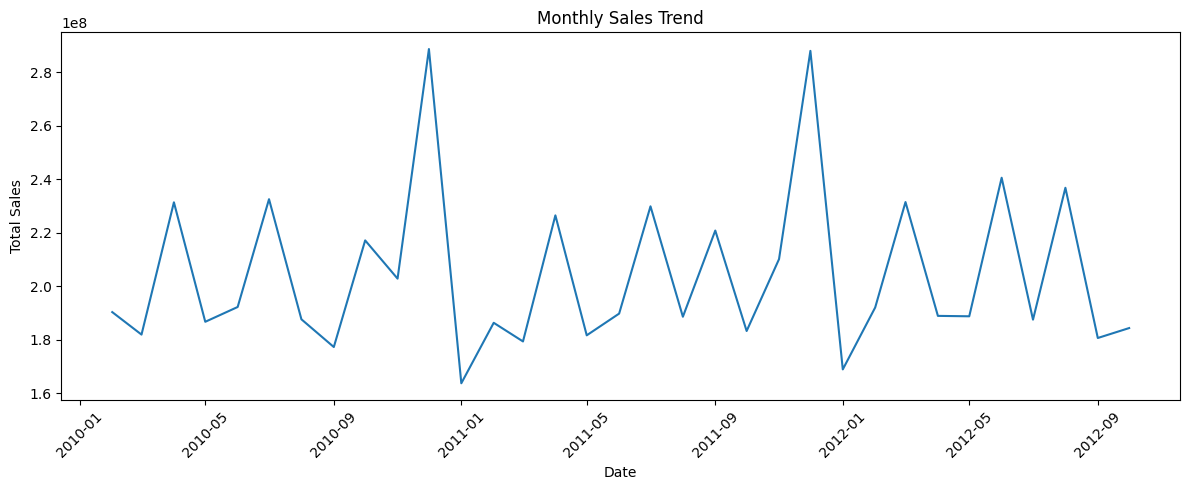

In [72]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_sales.index, monthly_sales.values)

plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [73]:
train_size = int(len(monthly_sales) * 0.80)

train = monthly_sales.iloc[:train_size]
test = monthly_sales.iloc[train_size:]

print("Training months:", len(train))
print("Testing months:", len(test))

Training months: 26
Testing months: 7


In [74]:
window = 3

history = list(train.values)
predictions = []

for i in range(len(test)):
    prediction = np.mean(history[-window:])
    predictions.append(prediction)
    history.append(test.iloc[i])

In [75]:
mae_ma = mean_absolute_error(test, predictions)
rmse_ma = np.sqrt(mean_squared_error(test, predictions))

print("Moving Average Forecast")
print("-----------------------")
print("MAE :", mae_ma)
print("RMSE:", rmse_ma)

Moving Average Forecast
-----------------------
MAE : 24234460.099523816
RMSE: 26784784.89610621


In [76]:
future_months = 6

history = list(monthly_sales.values)
future_predictions = []

for i in range(future_months):
    prediction = np.mean(history[-window:])
    future_predictions.append(prediction)
    history.append(prediction)

In [77]:
future_dates = pd.date_range(
    start=monthly_sales.index[-1] + pd.DateOffset(months=1),
    periods=future_months,
    freq='MS'
)

forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecasted_Sales': future_predictions
})

forecast_df

,Date,Forecasted_Sales
0,2012-11-01,2.006193e+08
1,2012-12-01,1.885422e+08
2,2013-01-01,1.911744e+08
3,2013-02-01,1.934453e+08
4,2013-03-01,1.910540e+08
5,2013-04-01,1.918912e+08


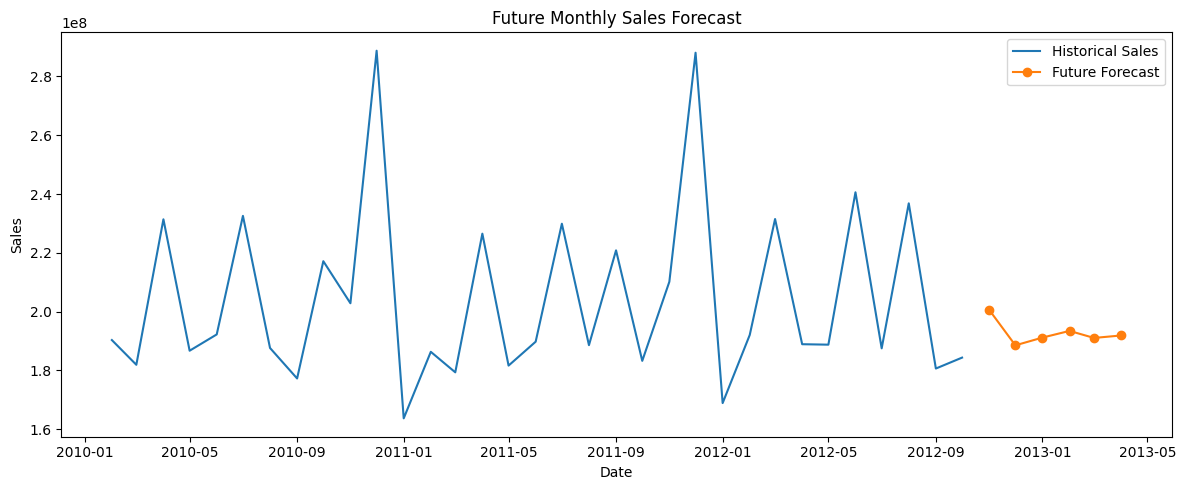

In [78]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    label='Historical Sales'
)

plt.plot(
    future_dates,
    future_predictions,
    marker='o',
    label='Future Forecast'
)

plt.title('Future Monthly Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()

plt.tight_layout()
plt.show()

In [79]:
final_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Tuned Random Forest',
        'Moving Average Forecast'
    ],
    'MAE': [
        mae_lr,
        mae_rf,
        mae_tuned,
        mae_ma
    ],
    'RMSE': [
        rmse_lr,
        rmse_rf,
        rmse_tuned,
        rmse_ma
    ],
    'R2': [
        r2_lr,
        r2_rf,
        r2_tuned,
        np.nan
    ]
})

final_results

,Model,MAE,RMSE,R2
0,Linear Regression,4.325950e+05,5.215835e+05,0.155532
1,Random Forest,6.202251e+04,1.141063e+05,0.959584
2,Tuned Random Forest,6.191456e+04,1.133073e+05,0.960148
3,Moving Average Forecast,2.423446e+07,2.678478e+07,NaN


## Business Insights

1. Weekly sales show noticeable variations over time, indicating the presence of seasonal and time-dependent patterns.

2. Sales performance varies significantly across different stores, indicating that store-level factors influence overall sales.

3. Holiday periods can affect sales patterns and should be considered when planning inventory and promotional activities.

4. The regression models demonstrate that historical, economic and environmental variables can be used to predict weekly sales.

5. Random Forest Regression is capable of capturing non-linear relationships between the input features and weekly sales.

6. Hyperparameter tuning using RandomizedSearchCV was performed to identify an improved Random Forest model configuration.

7. Time-series forecasting provides an estimate of future monthly sales based on historical sales patterns.

8. These predictions can help businesses with inventory planning, sales forecasting, promotional planning and resource allocation.

## Conclusion

This project implemented an end-to-end machine learning pipeline for Walmart sales data. The complete workflow included data preprocessing, exploratory data analysis, feature engineering, regression modeling, model evaluation, hyperparameter tuning and time-series forecasting.

Linear Regression was initially used as a baseline model. Random Forest Regression was then implemented to capture more complex and non-linear relationships in the sales data. The Random Forest model was further optimized using RandomizedSearchCV for hyperparameter tuning.

The models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE) and R² score. The results provide a comparison of the predictive performance of different regression approaches.

A time-series forecasting approach was also implemented using historical monthly sales. This provided estimates of future sales and demonstrated how historical sales patterns can be used for forecasting.

Overall, the project demonstrates a complete machine learning workflow, starting from raw sales data and ending with predictive modeling and future sales forecasting. The results can support business decisions related to inventory management, sales planning and resource allocation.

## Final Model Performance

The performance of the implemented models was evaluated using MAE, RMSE and R² score.

The model comparison table generated above shows the performance of Linear Regression, Random Forest Regression and the Tuned Random Forest model.

For MAE and RMSE, lower values indicate better predictive performance, while a higher R² score indicates that the model explains a larger proportion of the variation in weekly sales.

The tuned Random Forest model was selected based on its performance on the test dataset.

# Assignment 2: End-to-End Machine Learning Pipeline for Sales Prediction and Time-Series Forecasting

### Dataset: Walmart Sales Dataset

**Objective:**  
To design and implement an end-to-end machine learning pipeline covering data preprocessing, exploratory data analysis, feature engineering, regression modeling, hyperparameter tuning and time-series forecasting.

## Technologies and Libraries Used

- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Random Forest Regression
- Linear Regression
- RandomizedSearchCV
- Time-Series Forecasting

## Project Workflow

Raw Dataset
↓
Data Preprocessing
↓
Exploratory Data Analysis
↓
Feature Engineering
↓
Train-Test Split
↓
Regression Modeling
↓
Model Evaluation
↓
Hyperparameter Tuning
↓
Time-Series Analysis
↓
Sales Forecasting
↓
Business Insights
↓
Conclusion